In [3]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

plots_filepath = 'plots/august-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

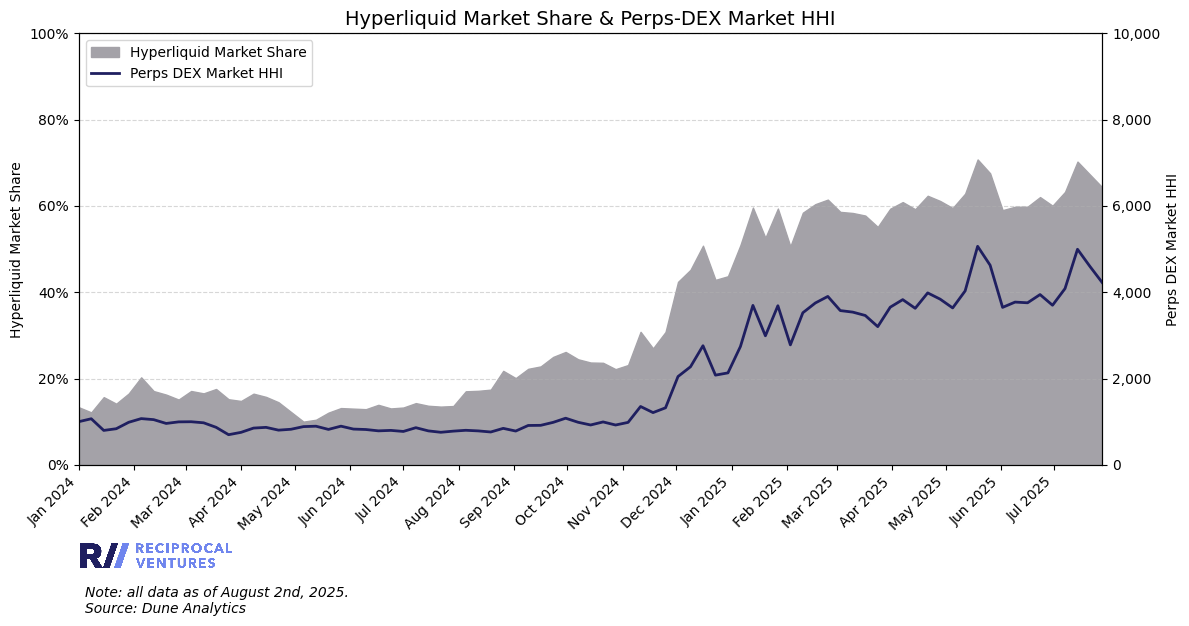

In [4]:
def plot_perpetual_volumes_from_json(json_path):
    # Load & parse the weekly JSON
    with open(json_path, 'r') as f:
        js = json.load(f)
    rows = js['result']['rows']
    df_w = pd.DataFrame(rows)
    # parse week → datetime
    df_w['date'] = pd.to_datetime(df_w['week'], utc=True)
    
    # Pivot so each row is a week, each column a product
    weekly = (
        df_w
        .pivot_table(
            index='date',
            columns='product_name',
            values='volume',
            aggfunc='sum'
        )
        .fillna(0)
    )
    
    # Compute total weekly volume & drop any weeks with zero total
    weekly['total_volume'] = weekly.sum(axis=1)
    weekly = weekly[weekly['total_volume'] > 0]

    # Market share (Hyperliquid) & HHI
    weekly['market_share'] = weekly['Hyperliquid Perps'] / weekly['total_volume'] * 100
    shares = weekly.drop(columns=['total_volume','market_share']).div(weekly['total_volume'], axis=0) * 100
    weekly['hhi'] = (shares ** 2).sum(axis=1)
    plot_df = weekly

    # Filter by index
    plot_df = plot_df[plot_df.index >= pd.to_datetime('2024-01-01', utc=True)]

    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Area: Hyperliquid 7-week avg share
    ax1.fill_between(
        plot_df.index, plot_df['market_share'],
        color="#a4a2a8", alpha=1,
        label="Hyperliquid Market Share"
    )
    ax1.set_ylabel("Hyperliquid Market Share")
    ax1.set_ylim(0, 100)
    ax1.yaxis.set_major_formatter(PercentFormatter())

    # X-axis from first → last
    ax1.set_xlim(plot_df.index[0], plot_df.index[-1])
    ax1.margins(x=0)
    fig.subplots_adjust(left=0.07)

    # Monthly tick locator & formatter
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Line: Perps-DEX HHI
    ax2 = ax1.twinx()
    ax2.plot(
        plot_df.index, plot_df['hhi'],
        color="#1f1f60", linewidth=2,
        label="Perps DEX Market HHI"
    )
    ax2.set_ylabel("Perps DEX Market HHI")
    ax2.set_ylim(0, 10_000)
    ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    # Title, grid & legend
    ax1.set_title(
        "Hyperliquid Market Share & Perps-DEX Market HHI",
        fontsize=14
    )
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")

    # Add logo & footer text
    add_logo(ax1, position=(0.075, -0.21))
    latest = plot_df.index[-1].strftime("%b %d, %Y")
    plt.figtext(
        0.075, -0.03,
        f"Note: all data as of {date}.\nSource: Dune Analytics",
        ha="left", fontsize=10, style="italic"
    )

    # tighten & save
    plt.tight_layout()
    os.makedirs("plots", exist_ok=True)
    plt.savefig(
        f"{plots_filepath}/hyperliquid_marketshare_hhi_7w.png",
        dpi=300, bbox_inches="tight"
    )
    plt.show()

# Usage
plot_perpetual_volumes_from_json("raw-data/dune-raw-data/dune_weekly-perps-dex-volumes.json")
